# xG Feature Importance Justification

As seen in the xG_player_scoring.ipynb, the evalaution metrics(i.e. accuracy, roc_auc, brier score, log loss), barely improve from the baseline to the model with the scoring feature added.

This notebook serves the justify this observation, by training the same models on the absense of the top 2 important features of each of the models, besides distance and angle. The top 8 important features for each model are as follows(see xG_player_scoring.ipynb);

        - For logistic Regression:      Feature                         Importance
                                    11    shot_technique_Half Volley    0.001768
                                    14  shot_technique_Overhead Kick    0.002479
                                    0                shot_aerial_won    0.005091
                                    15         shot_technique_Volley    0.006196
                                    17           shot_type_Free Kick    0.007186
                                    22                      Shooting    0.010569
                                    18           shot_type_Open Play    0.014091
                                    5            shot_body_part_Head    0.018921

        - For xGBoost:                  Feature                      Importance
                                    2              under_pressure    0.005251
                                    15      shot_technique_Volley    0.006154
                                    8   shot_body_part_Right Foot    0.006318
                                    0             shot_aerial_won    0.008690
                                    13      shot_technique_Normal    0.012210
                                    18        shot_type_Open Play    0.012782
                                    5         shot_body_part_Head    0.025830
                                    22                   Shooting    0.060650

        - For Random Forest:            Feature                      Importance
                                    0             shot_aerial_won    0.006912
                                    18        shot_type_Open Play    0.007130
                                    13      shot_technique_Normal    0.008032
                                    2              under_pressure    0.008363
                                    8   shot_body_part_Right Foot    0.009613
                                    1             shot_first_time    0.014125
                                    5         shot_body_part_Head    0.017395
                                    22                   Shooting    0.024903

        - For CatBoost:                 Feature                      Importance
                                    18         shot_type_Open Play    0.004825
                                    11  shot_technique_Half Volley    0.005074
                                    8    shot_body_part_Right Foot    0.008818
                                    1              shot_first_time    0.008902
                                    13       shot_technique_Normal    0.011086
                                    2               under_pressure    0.012789
                                    5          shot_body_part_Head    0.022474
                                    22                    Shooting    0.037884

The common 2, with differing importance, but comparable to shooting, by observation are: shot_body_part_Head and shot_type_Open Play.


In [1]:
import pandas as pd

shots = pd.read_csv("/Users/nanakwamekankam/Desktop/Football_Stats/xG/datasets/shots_extended.csv")
shots.head(10)

,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,goal,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,...,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle,Shooting
0,0,0,0.020838,0,0,0,0,0,0,0,...,0,0,0,1,0,107.1,26.6,0.272903,0.108401,0.637232
1,0,0,0.034462,0,0,0,0,0,0,0,...,0,0,0,1,0,113.7,54.0,0.222762,0.080550,0.680191
2,0,1,0.035481,1,0,0,0,0,1,0,...,0,0,0,1,0,115.7,50.5,0.160924,0.105901,0.830549
3,0,0,0.383711,0,0,0,0,1,0,0,...,0,0,0,1,0,113.9,38.6,0.082383,0.404258,0.680191
4,0,0,0.036740,0,0,0,0,0,0,0,...,0,0,0,1,0,96.7,47.2,0.362236,0.111442,0.780430
5,0,0,0.575428,0,0,0,0,0,0,0,...,0,0,0,1,0,111.3,38.7,0.121562,0.303973,0.875895
6,0,0,0.095998,0,0,0,0,0,0,0,...,0,0,0,1,0,112.6,28.7,0.194284,0.122250,0.637232
7,1,0,0.047259,1,0,0,0,1,0,0,...,0,0,0,1,0,112.1,32.8,0.150772,0.204760,0.780430
8,0,1,0.256448,0,0,0,0,0,0,0,...,0,0,0,1,0,108.4,43.0,0.170731,0.225333,0.737470
9,0,0,0.111973,0,0,0,0,0,1,0,...,0,0,0,1,0,114.2,27.2,0.202703,0.089450,0.875895


# MODELING

In [2]:
from sklearn.model_selection import train_test_split


y = shots['goal']
X1 = shots.drop(['goal', 'shot_statsbomb_xg', 'shot_body_part_Head' ], axis=1).copy()
X2 = shots.drop(['goal', 'shot_statsbomb_xg', 'shot_type_Open Play' ], axis=1).copy()

print(f"{X1.shape}, {y.shape}")
print(f"{X2.shape}, {y.shape}")

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.3, random_state=42)
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.3, random_state=42)

cordinates_1 = X1_test[['x', 'y']] # for model visualizations
cordinates_2 = X2_test[['x', 'y']] 

X1_train.drop(["x", "y"], axis=1, inplace=True)
X1_test.drop(["x", "y"], axis=1, inplace=True)

X2_train.drop(["x", "y"], axis=1, inplace=True)
X2_test.drop(["x", "y"], axis=1, inplace=True)


X1_train.head()

(9908, 24), (9908,)
(9908, 24), (9908,)


,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,shot_technique_Diving Header,...,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle,Shooting
3333,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0.116838,0.286246,0.546539
2166,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0.322302,0.124922,0.644391
8009,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0.367416,0.077479,0.818616
8299,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0.450847,0.091271,0.730310
2825,0,0,1,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0.121088,0.271665,0.914081


In [3]:
# from training_evaluation_pipeline import train

# cordinates, y_log, goal_log, y_rf, goal_rf, y_xgb, goal_xgb, y_cat, goal_cat, y_tabPFN, goal_tabPFN = train(shots, X1_train, y_train, X1_test, y_test) 

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from tabpfn_client import TabPFNClassifier, set_access_token


def train(X_train, y_train, X_test, y_test):
    # MODELING
    # LOGISTIC REGRESSION
    text = "Logistic Regression"
    print(f"{text.center(15, '-')}")

    logistic_regressor = LogisticRegression(max_iter=1000)
    logistic_regressor.fit(X_train, y_train)

    y_log= logistic_regressor.predict_proba(X_test)[:,1]
    goal_log = logistic_regressor.predict(X_test)

    log_df = X_test.copy()
    log_df['xG'] = y_log

    text = "Logistic Regression Complete 100/100"
    print(f"{text.center(15, '-')}")


    # RANDOM FORESTING
    text = "Random Forest"
    print(f"{text.center(15, '-')}")
    
    random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    # class_weight='balanced_subsample',
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
    )
    # try tuning parameters
    random_forest.fit(X_train, y_train)
    y_rf = random_forest.predict_proba(X_test)[:,1]
    goal_rf = random_forest.predict(X_test)

    rf_df = pd.DataFrame()
    rf_df['Goal'] = y_test.copy()
    rf_df['xG'] = y_rf

    text = "Random Forest Complete 100/100"
    print(f"{text.center(15, '-')}")

    # XGBOOST
    text = "XGBoosdt"
    print(f"{text.center(15, '-')}")


    xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='binary:logistic'
    )

    xgb_model.fit(X_train, y_train)
    y_xgb = xgb_model.predict_proba(X_test)[:,1]
    goal_xgb = xgb_model.predict(X_test)

    xgb_df = pd.DataFrame()
    xgb_df['Goal'] = y_test.copy()
    xgb_df['xG'] = y_xgb

    text = "XGBoost Complete 100/100"
    print(f"{text.center(15, '-')}")

    # CATBOOST
    text = "CatBoost"
    print(f"{text.center(15, '-')}")

    catBoost = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=10
    )

    catBoost.fit(X_train, y_train)
    y_cat = catBoost.predict_proba(X_test)[:,1]
    goal_cat = catBoost.predict(X_test)
    cat_df = pd.DataFrame()
    cat_df['Goal'] = y_test.copy()
    cat_df['xG'] = y_cat

    text = "CatBoost Complete 100/100"
    print(f"{text.center(15, '-')}")

    # TabFPN
    text = "Foundational Model Approach(TabFPN)"
    print(f"{text.center(15, '-')}")

    print("To use tabpfn:\n1. Open https://ux.priorlabs.ai in a browser and log in (or register)\n2. Accept the license on the Licenses tab\n3. Copy your API Key from https://ux.priorlabs.ai/account\n4. Set the environment variable: export TABPFN_TOKEN='<your-api-key>'")

    set_access_token("tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs")
    tabPFN = TabPFNClassifier()
    tabPFN.fit(X_train, y_train)
    goal_tabPFN = tabPFN.predict(X_test)
    y_tabPFN = tabPFN.predict_proba(X_test)[:,1]

    text = "TabPFN Complete 100/100"
    print(f"{text.center(15, '-')}")

    return y_log, goal_log, y_rf, goal_rf, y_xgb, goal_xgb, y_cat, goal_cat, y_tabPFN, goal_tabPFN


In [5]:
y_log1, goal_log1, y_rf1, goal_rf1, y_xgb1, goal_xgb1, y_cat1, goal_cat1, y_tabPFN1, goal_tabPFN1 = train(X1_train, y_train, X1_test, y_test)
print("Done Training without shot_body_part_Head\n")

y_log2, goal_log2, y_rf2, goal_rf2, y_xgb2, goal_xgb2, y_cat2, goal_cat2, y_tabPFN2, goal_tabPFN2 = train(X2_train, y_train, X2_test, y_test)
print("Done Training without shot_type_Open Play")

Logistic Regression
Logistic Regression Complete 100/100
-Random Forest-
Random Forest Complete 100/100
----XGBoosdt---
XGBoost Complete 100/100
----CatBoost---
0:	learn: 0.5946671	total: 58.5ms	remaining: 5.79s
10:	learn: 0.2979888	total: 79ms	remaining: 639ms
20:	learn: 0.2692089	total: 98.3ms	remaining: 370ms
30:	learn: 0.2622164	total: 120ms	remaining: 267ms
40:	learn: 0.2577958	total: 140ms	remaining: 201ms
50:	learn: 0.2539010	total: 163ms	remaining: 156ms
60:	learn: 0.2510368	total: 185ms	remaining: 118ms
70:	learn: 0.2482529	total: 200ms	remaining: 81.7ms
80:	learn: 0.2459804	total: 217ms	remaining: 50.8ms
90:	learn: 0.2433724	total: 236ms	remaining: 23.3ms
99:	learn: 0.2400575	total: 255ms	remaining: 0us
CatBoost Complete 100/100
Foundational Model Approach(TabFPN)
To use tabpfn:
1. Open https://ux.priorlabs.ai in a browser and log in (or register)
2. Accept the license on the Licenses tab
3. Copy your API Key from https://ux.priorlabs.ai/account
4. Set the environment variabl

The provided train set hashes match previously uploaded train sets.


00:02 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
00:00 Predicting... \

...

00:03 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
00:00 Predicting... |

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
TabPFN Complete 100/100
Done Training without shot_type_Open Play


## MODEL EVALUATION

In [6]:
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import pandas as pd


def evaluate_models(y_test, predictions, title):
    rows = []

    for model_name, values in predictions.items():
        y_prob = values["probability"]
        y_pred = values["prediction"]

        rows.append({
            "Experiment": title,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Log Loss": log_loss(y_test, y_prob),
            "ROC AUC": roc_auc_score(y_test, y_prob),
            "Brier Score": brier_score_loss(y_test, y_prob),
        })

    return pd.DataFrame(rows)

In [7]:
predictions_without_head = {
    "Logistic Regression": {"probability": y_log1, "prediction": goal_log1},
    "Random Forest": {"probability": y_rf1, "prediction": goal_rf1},
    "XGBoost": {"probability": y_xgb1, "prediction": goal_xgb1},
    "CatBoost": {"probability": y_cat1, "prediction": goal_cat1},
    "TabPFN": {"probability": y_tabPFN1, "prediction": goal_tabPFN1},
}

predictions_without_open_play = {
    "Logistic Regression": {"probability": y_log2, "prediction": goal_log2},
    "Random Forest": {"probability": y_rf2, "prediction": goal_rf2},
    "XGBoost": {"probability": y_xgb2, "prediction": goal_xgb2},
    "CatBoost": {"probability": y_cat2, "prediction": goal_cat2},
    "TabPFN": {"probability": y_tabPFN2, "prediction": goal_tabPFN2},
}

In [8]:
results_without_head = evaluate_models(
    y_test,
    predictions_without_head,
    "Without shot_body_part_Head"
)

results_without_open_play = evaluate_models(
    y_test,
    predictions_without_open_play,
    "Without shot_type_Open Play"
)

results = pd.concat(
    [results_without_head, results_without_open_play],
    ignore_index=True
)

results.sort_values(["Model", "Experiment"]).style.format({
    "Accuracy": "{:.5f}",
    "Log Loss": "{:.5f}",
    "ROC AUC": "{:.5f}",
    "Brier Score": "{:.5f}",
})


,Experiment,Model,Accuracy,Log Loss,ROC AUC,Brier Score
3,Without shot_body_part_Head,CatBoost,0.90918,0.26869,0.77772,0.07500
8,Without shot_type_Open Play,CatBoost,0.91221,0.26845,0.77763,0.07497
0,Without shot_body_part_Head,Logistic Regression,0.91019,0.26571,0.78061,0.07408
5,Without shot_type_Open Play,Logistic Regression,0.91019,0.26562,0.78071,0.07405
1,Without shot_body_part_Head,Random Forest,0.91154,0.26872,0.78139,0.07535
6,Without shot_type_Open Play,Random Forest,0.91154,0.26895,0.78045,0.07540
4,Without shot_body_part_Head,TabPFN,0.91154,0.26463,0.78947,0.07383
9,Without shot_type_Open Play,TabPFN,0.91187,0.26465,0.78846,0.07370
2,Without shot_body_part_Head,XGBoost,0.90986,0.26599,0.78481,0.07443
7,Without shot_type_Open Play,XGBoost,0.91086,0.26497,0.78535,0.07401


Confusion Matrices

In [9]:
def plot_confusion_matrices(y_test, predictions, title):
    for model_name, values in predictions.items():
        cm = confusion_matrix(y_test, values["prediction"])
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Miss", "Goal"]
        )
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"{title}: {model_name}")
        plt.show()

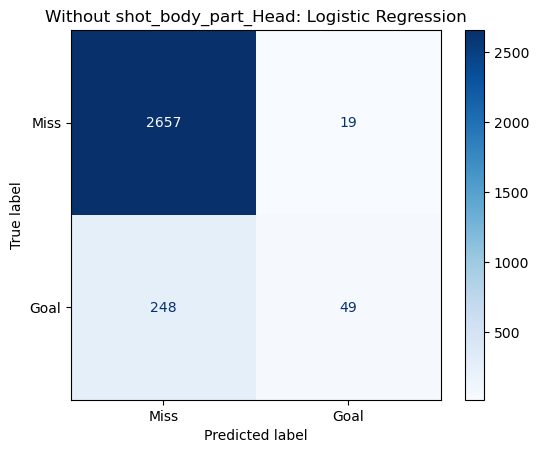

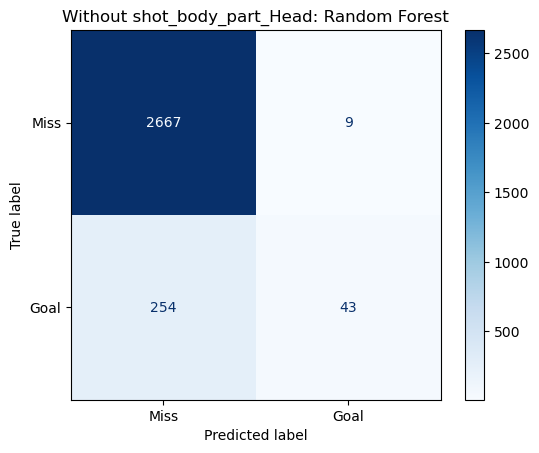

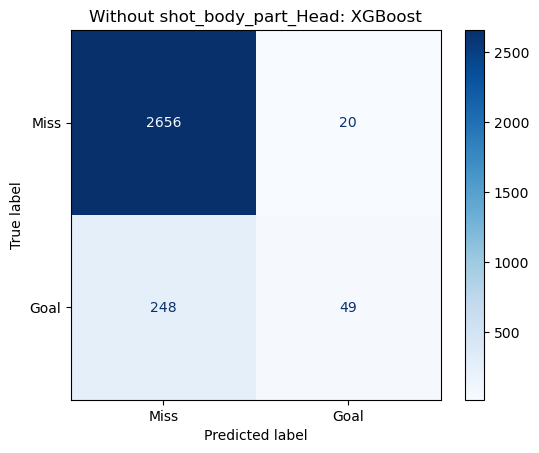

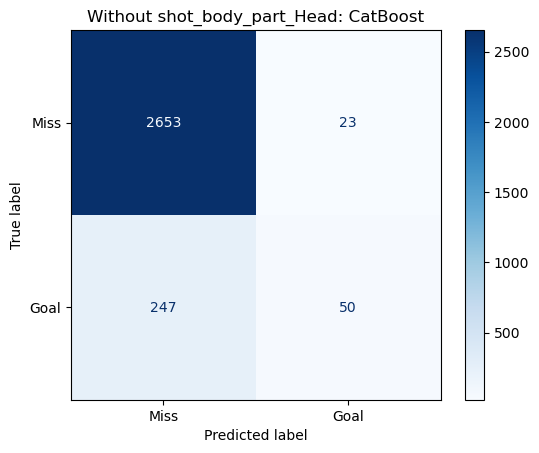

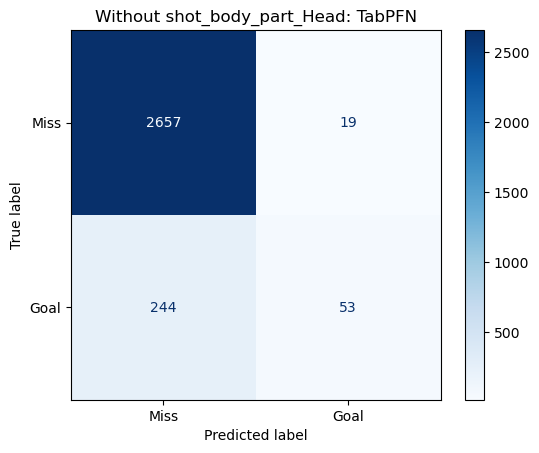

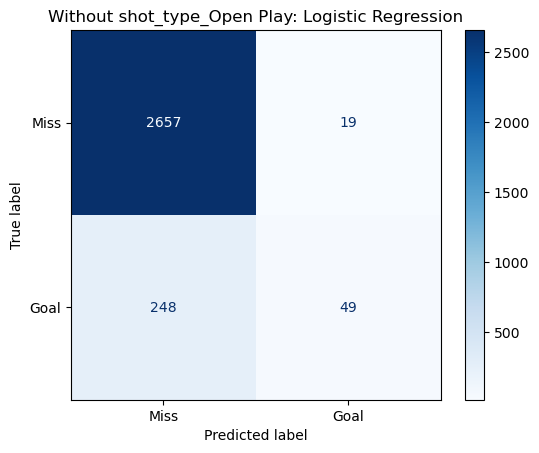

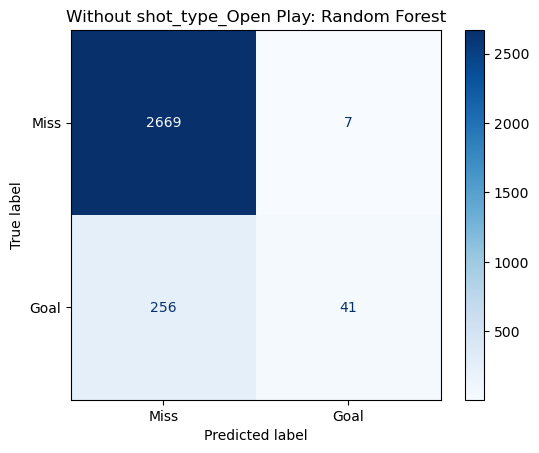

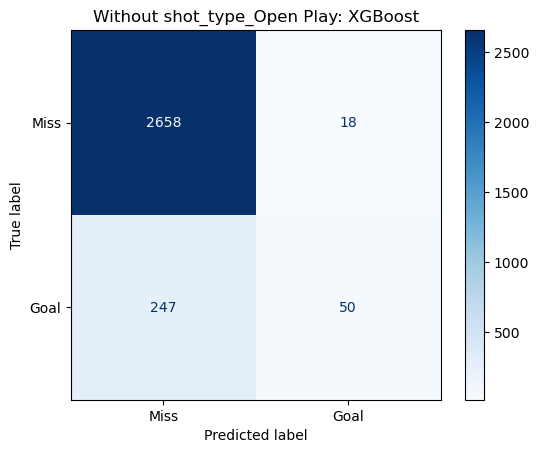

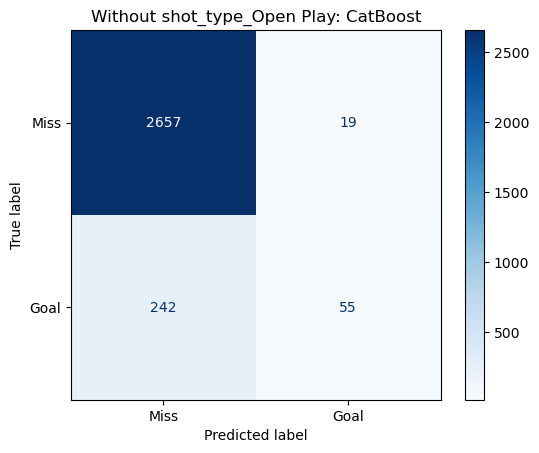

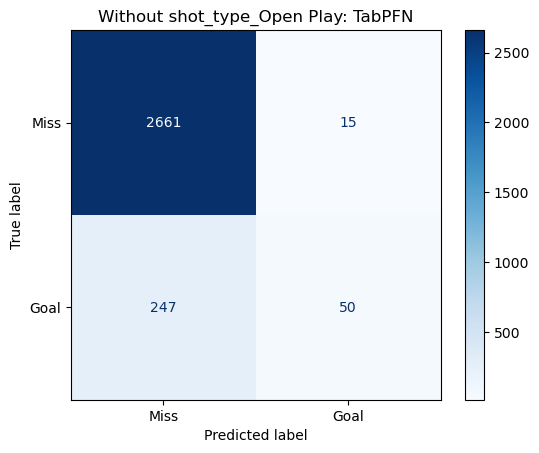

In [10]:
plot_confusion_matrices(
    y_test,
    predictions_without_head,
    "Without shot_body_part_Head"
)

plot_confusion_matrices(
    y_test,
    predictions_without_open_play,
    "Without shot_type_Open Play"
)

Calibration Curves

In [11]:
def plot_calibration_curves(y_test, predictions, title):
    plt.figure(figsize=(8, 6))

    for model_name, values in predictions.items():
        prob_true, prob_pred = calibration_curve(
            y_test,
            values["probability"],
            n_bins=10
        )
        plt.plot(prob_pred, prob_true, marker="o", label=model_name)

    plt.plot([0, 1], [0, 1], linestyle="--", color="black")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Observed Goal Frequency")
    plt.title(title)
    plt.legend()
    plt.show()

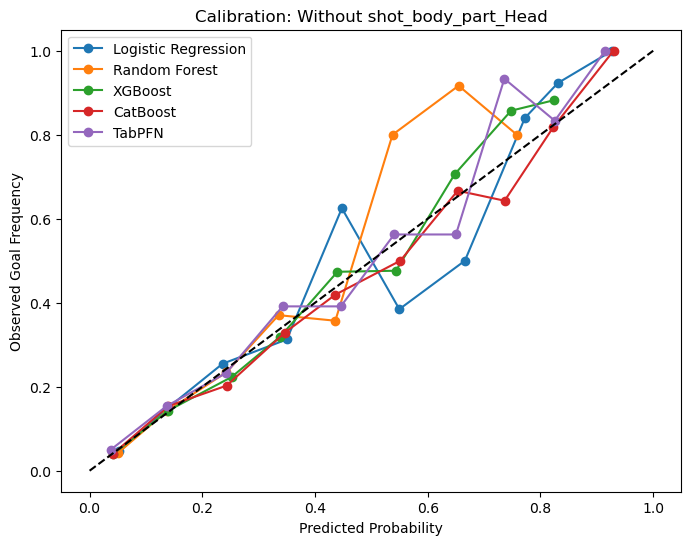

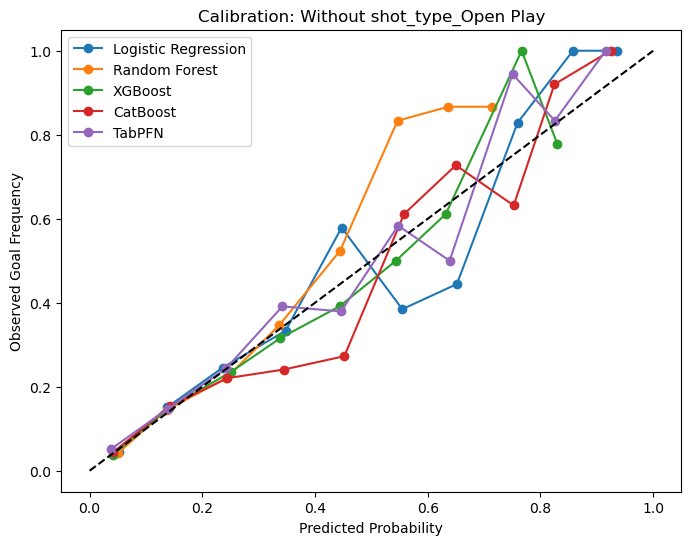

In [12]:
plot_calibration_curves(
    y_test,
    predictions_without_head,
    "Calibration: Without shot_body_part_Head"
)

plot_calibration_curves(
    y_test,
    predictions_without_open_play,
    "Calibration: Without shot_type_Open Play"
)